# Prithvi-UNet Phase-2 Refinement Training: SA T2 ACCESS-CM2 (static)

This notebook trains the **Phase-2 stochastic residual refiner** on top of a frozen Phase-1 deterministic UNet checkpoint.

Four refinement architectures are available — select one by pointing `CONFIG_PATH` at the corresponding YAML:

| YAML file | Refinement type | Notes |
|---|---|---|
| `SA_T2_ACCESS-CM2_static_diffusion_unet.yaml` | `diffusion_unet` | DDIM, cosine schedule, η=0 |
| `SA_T2_ACCESS-CM2_static_flow_matching_unet.yaml` | `flow_matching_unet` | Euler ODE solver |
| `SA_T2_ACCESS-CM2_static_diffusion_transformer.yaml` | `diffusion_transformer` | ViT backbone |
| `SA_T2_ACCESS-CM2_static_flow_matching_transformer.yaml` | `flow_matching_transformer` | Heun ODE solver |

All four train on the residual `target − UNet_output` with Phase 1 frozen.

---
## Setup

Python ≥ 3.10 required. Make sure the current working directory is `granite-wxc/`.

In [1]:
import os
import sys
from pathlib import Path

# Resolve repo root relative to this notebook's location
REPO_ROOT = Path(__file__).resolve().parents[3] if "__file__" in dir() else Path.cwd().parents[2]
# Fallback: walk up from cwd until we find the repo marker
if not (REPO_ROOT / "examples" / "CORDEX_ML").exists():
    _here = Path.cwd()
    for _p in [_here, *_here.parents]:
        if (_p / "examples" / "CORDEX_ML").exists():
            REPO_ROOT = _p
            break

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(str(REPO_ROOT / "examples/CORDEX_ML"))
print(f"Repo root        : {REPO_ROOT}")
print(f"Working directory: {Path.cwd()}")

Repo root        : d:\granite-wxc
Working directory: d:\granite-wxc\examples\CORDEX_ML


In [2]:
# ===================== CONFIGURATION / HARDWARE (EDIT ME) =====================
import subprocess

# --- refinement YAML to use (edit this line to switch architectures) ---
CONFIG_YAML = "SA_T2_ACCESS-CM2_static_flow_matching_unet.yaml"

# --- training options ---
resume_from_checkpoint = False      # set True to resume from checkpoint_dir/last.ckpt
resume_checkpoint_path = None       # optional explicit path override
seed = 42

# --- GPU selection ---
max_gpus = 1
force_visible_devices = None        # e.g. "2" to pin to physical GPU 2

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


def _query_gpu_stats():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=index,memory.total,memory.used,utilization.gpu",
             "--format=csv,noheader,nounits"], text=True,
        )
    except Exception:
        return []
    stats = []
    for line in out.strip().splitlines():
        idx, total, used, util = [p.strip() for p in line.split(",")]
        util_n = int("".join(c for c in util if c.isdigit()) or "100")
        total_mb, used_mb = int(total), int(used)
        stats.append({"index": int(idx), "total_mb": total_mb, "used_mb": used_mb,
                      "free_mb": max(0, total_mb - used_mb), "util": util_n})
    return stats


gpu_stats = _query_gpu_stats()
if force_visible_devices:
    os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    os.environ["CUDA_VISIBLE_DEVICES"] = str(force_visible_devices)
    selected = [int(x.strip()) for x in str(force_visible_devices).split(",") if x.strip()]
elif gpu_stats:
    ranked = sorted(gpu_stats, key=lambda g: (-g["free_mb"], g["util"]))
    selected = [g["index"] for g in ranked[:max_gpus]]
    os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(i) for i in selected)
else:
    selected = []

USE_GPU = bool(selected)
print(f"Selected physical GPUs: {selected}")
print(f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES', '<unset>')}")
for s in selected:
    stat = next((g for g in gpu_stats if g["index"] == s), None)
    if stat:
        print(f"  GPU {s}: {stat['free_mb']/1024:.1f} GB free / {stat['total_mb']/1024:.1f} GB total  util={stat['util']}%")

Selected physical GPUs: [0]
CUDA_VISIBLE_DEVICES=0
  GPU 0: 92.4 GB free / 95.6 GB total  util=15%


In [3]:
import logging
import warnings

import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from granitewxc.utils.config import get_config
from granitewxc.models.model import get_finetune_model_UNET
from granitewxc.refinement.two_phase import build_two_phase_model
from granitewxc.refinement.training import RefinementTrainer
from granitewxc.refinement.checkpoint import load_phase1_state_dict
from granitewxc.utils.predictands import build_predictand_specs

logging.disable(logging.CRITICAL)
warnings.simplefilter("ignore", FutureWarning)

os.chdir(str(REPO_ROOT / "examples/CORDEX_ML"))

# Import the same dataloader utilities used by the Phase-1 notebook
sys.path.insert(0, str(REPO_ROOT / "examples/CORDEX_ML"))
from cordex_refinement_training import _build_loaders

print("Imports OK.")

Imports OK.


---
## Load configuration

In [4]:
PROJECT_DIR = REPO_ROOT / "examples/CORDEX_ML"
CONFIG_PATH = PROJECT_DIR / CONFIG_YAML

config = get_config(str(CONFIG_PATH))

# Notebook-safe overrides: single worker, no pin_memory to avoid CUDA allocator pressure
config.batch_size = 1
config.dl_num_workers = 2
config.dl_prefetch_size = 0
config.dl_pin_memory = False
config.device_target = "cuda" if USE_GPU else "cpu"

# Keep geometry fixed
config.data.train_crop_size_lat = int(config.data.target_size_lat)
config.data.train_crop_size_lon = int(config.data.target_size_lon)
config.data.val_crop_size_lat = int(config.data.target_size_lat)
config.data.val_crop_size_lon = int(config.data.target_size_lon)

def _resolve_repo_path(value):
    path = Path(value).expanduser()
    return path.resolve() if path.is_absolute() else (REPO_ROOT / path).resolve()

def _resolve_project_path(value):
    path = Path(value).expanduser()
    return path.resolve() if path.is_absolute() else (PROJECT_DIR / path).resolve()

# Experiment outputs belong to this example project.
config.path_experiment = str(_resolve_project_path(config.path_experiment))

# model.refinement and model.phase1 are stored as plain dicts by ModelConfig
refinement_type = config.model.refinement["type"]
configured_checkpoint_dir = getattr(config, "checkpoint_dir",
    Path("experiments/refinement_checkpoints/SA_T2_ACCESS-CM2_static") / refinement_type)
checkpoint_dir = str(_resolve_project_path(configured_checkpoint_dir))
config.checkpoint_dir = checkpoint_dir
phase1_ckpt_path = str(_resolve_repo_path(config.model.phase1["checkpoint"]))

print(f"Config          : {CONFIG_PATH}")
print(f"Refinement type : {refinement_type}")
print(f"Phase-1 ckpt    : {phase1_ckpt_path}")
print(f"Checkpoint dir  : {checkpoint_dir}")
print(f"Epochs          : {config.num_epochs}")
print(f"Learning rate   : {config.learning_rate}")

Config          : d:\granite-wxc\examples\CORDEX_ML\SA_T2_ACCESS-CM2_static_flow_matching_unet.yaml
Refinement type : flow_matching_unet
Phase-1 ckpt    : D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\phase1_unet\best.ckpt
Checkpoint dir  : D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\SA_T2_ACCESS-CM2_static_flow_matching_unet_schema2_signed_log_fixed
Epochs          : 100
Learning rate   : 5e-05


---
## Build dataloaders

In [5]:
train_dl, val_dl, validation_source = _build_loaders(
    config, use_gpu=USE_GPU, tiny_overfit=False, validation_fraction=0.1
)
print(f"Validation split: {validation_source}")
print(f"Train batches: {len(train_dl)}   Val batches: {len(val_dl)}")

sample = next(iter(train_dl))
print(f"x shape      : {tuple(sample['x'].shape)}")
print(f"y shape      : {tuple(sample['y'].shape)}")
if 'static_x' in sample:
    print(f"static_x     : {tuple(sample['static_x'].shape)}")

d:\granite-wxc\examples\CORDEX_ML\cordex_dataset.py:639: RuntimeWarning: xESMF could not be imported; falling back to xarray interpolation (ModuleNotFoundError: No module named 'xesmf').
  warnings.warn(


[data] random_crop requested but disabled because crop_size=128x128 covers full grid 128x128. Set data.train_crop_size_lat/lon smaller than the target grid to enable crop augmentation.


d:\granite-wxc\examples\CORDEX_ML\cordex_dataset.py:639: RuntimeWarning: xESMF could not be imported; falling back to xarray interpolation (ModuleNotFoundError: No module named 'xesmf').
  warnings.warn(


[data] identical validation paths detected; using disjoint chronological holdout (13140 train, 1460 validation samples).
Validation split: automatic chronological holdout from identical YAML paths
Train batches: 13140   Val batches: 1460
x shape      : (1, 15, 128, 128)
y shape      : (1, 2, 128, 128)
static_x     : (1, 1, 128, 128)


---
## Build models and load Phase-1 checkpoint

In [6]:
if not config.data.__dict__.get('input_static_surface_vars'):
    config.data.input_static_surface_vars = []

predictand_specs = build_predictand_specs(
    config, output_vars=list(getattr(config.data, 'output_vars', []))
)
print("Predictand specs:")
for spec in predictand_specs:
    print(f"  {spec.name}: nonnegativity={spec.nonnegativity.enabled}, "
          f"scaling={spec.scaling.method}")

# Step 1 — build the bare Phase-1 model (weights uninitialised at this point).
phase1_model = get_finetune_model_UNET(config)

# Step 2 — wrap in TwoPhaseDownscalingModel before loading the checkpoint.
# load_phase1_state_dict migrates keys to the 'phase1.*' prefix, so the target
# must be the wrapper (which owns a 'phase1' sub-module), not the bare model.
device = torch.device("cuda:0" if USE_GPU and torch.cuda.is_available() else "cpu")
model = build_two_phase_model(phase1_model, config).to(device)

# Step 3 — load the checkpoint into the wrapper.
print(f"\nLoading Phase-1 checkpoint from:\n  {phase1_ckpt_path}")
raw_ckpt = torch.load(phase1_ckpt_path, map_location="cpu", weights_only=False)
report = load_phase1_state_dict(model, raw_ckpt)
print(f"Load report: {report.summary()}")

# Step 4 — initialise the lazy refiner network from a real data batch.
_init_batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in sample.items()}
model.initialize_from_batch(_init_batch)
del _init_batch

p1_params = sum(p.numel() for p in model.phase1.parameters())
p2_params = sum(p.numel() for p in model.refiner.parameters()) if model.refiner else 0
trainable = sum(p.numel() for p in model.trainable_parameters())
print(f"\nPhase-1 parameters : {p1_params:,}  (frozen={model.phase1_frozen})")
print(f"Phase-2 parameters : {p2_params:,}")
print(f"Trainable          : {trainable:,}")
for k, v in model.describe().items():
    if k not in ("refinement", "performance"):
        print(f"  {k}: {v}")

[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
Predictand specs:
  pr: nonnegativity=True, scaling=divide_only
  tasmax: nonnegativity=False, scaling=zscore
Creating the model.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> model has 246,408,968 params.


c:\Users\huikyole\AppData\Local\miniforge3\envs\Prithvi\Lib\site-packages\torch\nn\modules\module.py:1370: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(



Loading Phase-1 checkpoint from:
  D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\phase1_unet\best.ckpt
Load report: loaded=208 missing=6 unexpected=0 shape_mismatched=0 renamed=208

Phase-1 parameters : 246,474,538  (frozen=True)
Phase-2 parameters : 2,358,530
Trainable          : 2,358,530
  phase1_frozen: True
  phase1_features: []
  phase1_parameters: 246474538
  refiner_parameters: 2358530


---
## Optimizer, scheduler, and scaler

In [7]:
accum_steps = int(getattr(config, "gradient_accumulation_steps", 1))
limit_train = int(getattr(config, "limit_steps_train", 0))
effective_steps = min(len(train_dl), limit_train) if limit_train > 0 else len(train_dl)
optimizer_steps_per_epoch = max(1, (effective_steps + accum_steps - 1) // accum_steps)
total_steps = config.num_epochs * optimizer_steps_per_epoch

optimizer = AdamW(model.trainable_parameters(), lr=config.learning_rate)
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=config.min_lr)

amp_cls = getattr(getattr(torch, "amp", None), "GradScaler", None)
if amp_cls is None:
    from torch.cuda.amp import GradScaler as amp_cls  # type: ignore[assignment]
try:
    scaler = amp_cls("cuda", enabled=USE_GPU and torch.cuda.is_available())
except TypeError:
    scaler = amp_cls(enabled=USE_GPU and torch.cuda.is_available())

print(f"Optimizer        : AdamW  lr={config.learning_rate}  min_lr={config.min_lr}")
print(f"Scheduler        : CosineAnnealingLR  T_max={total_steps}")
print(f"Grad accum steps : {accum_steps}")
print(f"Effective batch  : {accum_steps * config.batch_size}")

Optimizer        : AdamW  lr=5e-05  min_lr=1e-06
Scheduler        : CosineAnnealingLR  T_max=41100
Grad accum steps : 32
Effective batch  : 32


---
## Build RefinementTrainer

In [8]:
import yaml as _yaml
try:
    resolved_cfg = _yaml.safe_load(CONFIG_PATH.read_text())
except Exception:
    resolved_cfg = {}

trainer = RefinementTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    checkpoint_dir=checkpoint_dir,
    phase1_checkpoint=phase1_ckpt_path,
    resolved_config=resolved_cfg,
    case_name=str(getattr(config, "case_name", "cordex_sa_t2_access_cm2_static")),
    gradient_accumulation_steps=accum_steps,
    max_grad_norm=1.0,
    seed=seed,
    log_every=50,
)

_should_resume = resume_from_checkpoint or bool(getattr(config, "resume_training", False))
_resume_path = (
    resume_checkpoint_path
    or getattr(config, "resume_checkpoint_path", None)
    or str(Path(checkpoint_dir) / "last.ckpt")
)

if _should_resume:
    state = trainer.resume(_resume_path)
    print(f"Resumed from {_resume_path} at epoch={state.epoch} step={state.global_step}")
else:
    if any((Path(checkpoint_dir) / name).exists() for name in ("best.ckpt", "last.ckpt")):
        raise FileExistsError(
            "Fresh notebook training would replace an existing refinement run. "
            "Select a new checkpoint_dir (see refinement_audit_configs), or explicitly resume compatible weights."
        )
    print(f"Starting fresh Phase-2 training for '{refinement_type}'.")

print(f"Checkpoint dir: {checkpoint_dir}")

Starting fresh Phase-2 training for 'flow_matching_unet'.
Checkpoint dir: D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\SA_T2_ACCESS-CM2_static_flow_matching_unet_schema2_signed_log_fixed


---
## Train

In [9]:
limit_valid = int(getattr(config, "limit_steps_valid", 100))
target_epochs = int(config.num_epochs)
completed_epochs = int(trainer.state.epoch)
remaining_epochs = max(0, target_epochs - completed_epochs)
print(
    f"Training target: epoch {target_epochs} "
    f"({completed_epochs} completed, {remaining_epochs} remaining)."
)

state = trainer.fit(
    train_loader=train_dl,
    val_loader=val_dl,
    num_epochs=remaining_epochs,
    limit_steps_train=limit_train,
    limit_steps_valid=limit_valid,
    show_progress=True,  # one notebook-visible train+validation bar per epoch
)

print(f"\nTraining complete: {state.epoch} epochs, {state.global_step} optimizer steps.")
print(f"Best val loss: {state.best_val_loss:.6f}")

Training target: epoch 100 (0 completed, 100 remaining).
[refinement] fitting physical residual statistics on training split


Epoch 001/100 residual stats:   0%|          | 0/26380 [00:00<?, ?batch/s]

[refinement] residual normalization fitted: {'method': 'standardize', 'epsilon': 1e-06, 'minimum_scale': 0.0001, 'require_fitted': True, 'fitted': True, 'count': [215285760.0, 215285760.0], 'mean': [-0.18619123394238393, 0.0404894948259417], 'scale': [1.0840765450721697, 1.6125952321022843], 'signed_log_nonnegative_channels': True, 'signed_log_scale': 1.0, 'signed_log_mask': [True, False], 'channel_names': ['pr', 'tasmax']}
Ep 001  train=2.1336  val=2.3408  best=2.3408  *** new best ***
[refinement] saved refinement checkpoint -> D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\SA_T2_ACCESS-CM2_static_flow_matching_unet_schema2_signed_log_fixed\last.ckpt


Epoch 002/100 train:   0%|          | 0/13240 [00:00<?, ?batch/s]

Ep 002  train=2.0095  val=2.2100  best=2.2100  *** new best ***
[refinement] saved refinement checkpoint -> D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\SA_T2_ACCESS-CM2_static_flow_matching_unet_schema2_signed_log_fixed\last.ckpt


...

Ep 098  train=0.4539  val=0.5839  best=0.5826
[refinement] saved refinement checkpoint -> D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\SA_T2_ACCESS-CM2_static_flow_matching_unet_schema2_signed_log_fixed\last.ckpt


Epoch 099/100 train:   0%|          | 0/13240 [00:00<?, ?batch/s]

Ep 099  train=0.4536  val=0.5838  best=0.5826
[refinement] saved refinement checkpoint -> D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\SA_T2_ACCESS-CM2_static_flow_matching_unet_schema2_signed_log_fixed\last.ckpt


Epoch 100/100 train:   0%|          | 0/13240 [00:00<?, ?batch/s]

Ep 100  train=0.4531  val=0.5823  best=0.5823  *** new best ***
[refinement] saved refinement checkpoint -> D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\SA_T2_ACCESS-CM2_static_flow_matching_unet_schema2_signed_log_fixed\last.ckpt

Training complete: 100 epochs, 41100 optimizer steps.
Best val loss: 0.582299


---
## Loss curves

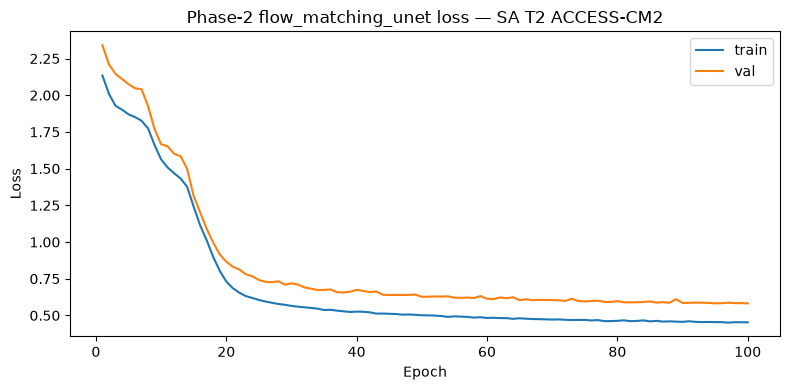

In [10]:
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 4))
    epochs = list(range(1, len(state.train_loss_history) + 1))
    ax.plot(epochs, state.train_loss_history, label="train")
    if state.val_loss_history:
        ax.plot(epochs, state.val_loss_history, label="val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Phase-2 {refinement_type} loss — SA T2 ACCESS-CM2")
    ax.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available; skipping plot.")
    print("Train losses:", state.train_loss_history)
    print("Val losses  :", state.val_loss_history)

---
## Checkpoint summary

In [11]:
ckpt_dir = Path(checkpoint_dir)
print(f"Checkpoints in {ckpt_dir}:")
for f in sorted(ckpt_dir.glob("*.ckpt")):
    size_mb = f.stat().st_size / 1024**2
    print(f"  {f.name:30s}  {size_mb:.1f} MB")
print()
best_path = ckpt_dir / "best.ckpt"
if best_path.exists():
    print(f"Best checkpoint : {best_path}")
    print(f"  -> Set model.refinement.checkpoint in your inference YAML to this path.")

Checkpoints in D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\SA_T2_ACCESS-CM2_static_flow_matching_unet_schema2_signed_log_fixed:
  best.ckpt                       27.1 MB
  last.ckpt                       27.1 MB

Best checkpoint : D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\SA_T2_ACCESS-CM2_static_flow_matching_unet_schema2_signed_log_fixed\best.ckpt
  -> Set model.refinement.checkpoint in your inference YAML to this path.


## Four-option audit and fresh training
The loader above now uses the same disjoint chronological split as the training CLI. Earlier saved notebook outputs predate this correction: identical training/validation file lists previously reused training dates. Those existing checkpoints and outputs are preserved, but their reported validation loss is not held-out evidence.

Eight isolated configurations (four heads, each with legacy and coordinate-aligned geometry) are in `../refinement_audit_configs/`. Select one in `CONFIG_PATH` for fresh training; never resume a checkpoint with a changed learned geometry. The legacy/coordinates pair changes only the geometry setting. Do not claim scientific improvement until both targets pass separate validation.

From the repository root, the paired subset audit runs all four options using one frozen Phase-1 cache:
```powershell
mamba run -n Prithvi python examples/CORDEX_ML/cordex_refinement_audit.py --config examples/CORDEX_ML/SA_T2_ACCESS-CM2_static_flow_matching_unet.yaml --output-dir artifacts/refinement_validation/fresh_four_option_audit
```
Subset training is a learning diagnostic. Use the normal training CLI for full training and the strict output evaluator for final climate comparisons.

Input-scaling-only recipes use `audit_normalized` in the same configuration directory. They are experimental; the short paired audit does not support promoting this change for every head and variable.
For normal inference stage diagnostics set `GRANITE_REFINEMENT_SAVE_SAMPLING_STATES=1`. The callback saves real sampler states without drawing extra noise.


## Registered scientific experiments
The frozen acceptance contract and the registered experiment plan are separate from the earlier audit. 
Scientific training uses the same implementation from this notebook and the normal training CLI: 
`cordex_refinement_training.main(["--scientific-experiment", "train", ...])`. 
Use `cordex_scientific_experiments.py train --help` for the explicit cache, plan, recipe, seed and resumable output arguments. 
Prediction uses the corresponding normal inference script with `--scientific-experiment predict ...`. 
The original model/outputs above are retained. A candidate or smoke run is not scientific acceptance.
For a compatible direct-residual checkpoint through the original driver, set `GRANITE_REFINEMENT_SAMPLING_MODE=stable` 
to obtain date/member-keyed samples; `legacy` remains explicit for engineering replay. 
Stable raw member prefixes are nested, but coupled precipitation postprocessing must be rerun at each ensemble size.


In [12]:
# Explicit scientific entry point; shares implementation with the normal CLI.
# Set RUN_SCIENTIFIC_EXPERIMENT after choosing a registered head and output.
RUN_SCIENTIFIC_EXPERIMENT = False
SCIENTIFIC_HEAD = "diffusion_unet"
SCIENTIFIC_RUN = PROJECT_DIR.parent.parent / "artifacts/refinement_validation/scientific_acceptance_20260909T230807Z"
SCIENTIFIC_ARGS = [
    "--scientific-experiment", "train",
    "--config", str(PROJECT_DIR / f"SA_T2_ACCESS-CM2_static_{SCIENTIFIC_HEAD}.yaml"),
    "--cache", str(SCIENTIFIC_RUN / "cache/phase1.h5"),
    "--plan", str(SCIENTIFIC_RUN / "registered_experiment_plan.json"),
    "--contract", str(SCIENTIFIC_RUN / "frozen_scientific_acceptance_v2.json"),
    "--output", str(SCIENTIFIC_RUN / "notebook_runs" / SCIENTIFIC_HEAD),
    "--head", SCIENTIFIC_HEAD, "--recipe", "native", "--formulation", "direct",
    "--stage", "overfit", "--seed", "101", "--device", "cuda:0",
]
if RUN_SCIENTIFIC_EXPERIMENT:
    import cordex_refinement_training
    scientific_exit_code = cordex_refinement_training.main(SCIENTIFIC_ARGS)
    if scientific_exit_code:
        raise RuntimeError(f"Scientific run unfinished or failed (exit {scientific_exit_code}); inspect its saved execution state.")
